In [11]:
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as ipd
import librosa
import librosa.display
import soundfile as sf
import os


In [12]:
AUDIO_DIR = "/home/bella/Desktop/chalmers/AML/Project/data/fma_small"
METADATA_DIR = "/home/bella/Desktop/chalmers/AML/Project/data/fma_metadata"

# STFT parameters
fft_size = 2048
step_size = fft_size // 10   # hop length
N_FREQ_BINS = 64             # how many frequency bins to keep
DURATION = 5                 # seconds to load per track
SR = 44100                   # sample rate

In [13]:
import pandas as pd
import ast

def load_tracks(filepath):
    tracks = pd.read_csv(filepath, index_col=0, header=[0, 1])
    COLUMNS = [('track', 'tags'), ('album', 'tags'), ('artist', 'tags'),
               ('track', 'genres'), ('track', 'genres_all')]
    for column in COLUMNS:
        tracks[column] = tracks[column].map(ast.literal_eval)
    COLUMNS = [('track', 'date_created'), ('track', 'date_recorded'),
               ('album', 'date_created'), ('album', 'date_released'),
               ('artist', 'date_created'), ('artist', 'active_year_begin'),
               ('artist', 'active_year_end')]
    for column in COLUMNS:
        tracks[column] = pd.to_datetime(tracks[column])
    SUBSETS = ('small', 'medium', 'large')
    tracks['set', 'subset'] = pd.Categorical(
        tracks['set', 'subset'], categories=SUBSETS, ordered=True)
    COLUMNS = [('track', 'genre_top'), ('track', 'license'),
               ('album', 'type'), ('album', 'information'),
               ('artist', 'bio')]
    for column in COLUMNS:
        tracks[column] = tracks[column].astype('category')
    return tracks

tracks = load_tracks(os.path.join(METADATA_DIR, 'tracks.csv'))
small = tracks['set', 'subset'] <= 'small'
tracks_small = tracks[small]

electronic = tracks_small['track', 'genre_top'] == 'Electronic'
electronic_tracks = tracks_small[electronic]

print(f"Number of electronic tracks: {len(electronic_tracks)}")

Number of electronic tracks: 1000


In [14]:
def get_audio_path(audio_dir, track_id):
    tid_str = '{:06d}'.format(track_id)
    return os.path.join(audio_dir, tid_str[:3], tid_str + '.mp3')

electronic_index = electronic_tracks.index.values
electronic_paths = [get_audio_path(AUDIO_DIR, i) for i in electronic_index]

print(f"First path: {electronic_paths[0]}")

First path: /home/bella/Desktop/chalmers/AML/Project/data/fma_small/001/001482.mp3


In [21]:
# Pick one track
test_path = electronic_paths[26]

# Load with librosa
y, sr = librosa.load(test_path, sr=SR, mono=True, duration=DURATION)
print(f"Waveform shape: {y.shape}, sample rate: {sr}")

# Compute complex STFT — DO NOT take abs(), keep complex
stft_complex = librosa.stft(y, n_fft=fft_size, hop_length=step_size)
print(f"Full STFT shape: {stft_complex.shape}")  # (1025, time_frames)

# Crop to N_FREQ_BINS
stft_cropped = stft_complex[:N_FREQ_BINS, :]
print(f"Cropped STFT shape: {stft_cropped.shape}")  # (64, time_frames)

# Split into 2 channels
real_part = stft_cropped.real   # (64, time_frames)
imag_part = stft_cropped.imag   # (64, time_frames)
two_channel = np.stack([real_part, imag_part], axis=0)  # (2, 64, time_frames)
print(f"Two-channel shape: {two_channel.shape}")

Waveform shape: (220500,), sample rate: 44100
Full STFT shape: (1025, 1081)
Cropped STFT shape: (64, 1081)
Two-channel shape: (2, 64, 1081)


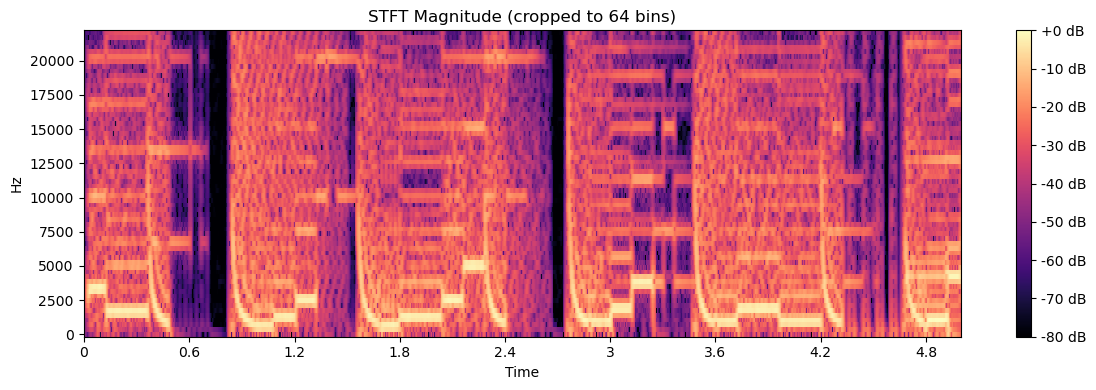

In [22]:
magnitude = np.abs(stft_cropped)
magnitude_db = librosa.amplitude_to_db(magnitude, ref=np.max)

plt.figure(figsize=(12, 4))
librosa.display.specshow(magnitude_db, sr=SR, hop_length=step_size, 
                         x_axis='time', y_axis='hz')
plt.colorbar(format='%+2.0f dB')
plt.title('STFT Magnitude (cropped to 64 bins)')
plt.tight_layout()
plt.show()

In [23]:
# Rebuild complex STFT from 2 channels
stft_reconstructed = two_channel[0] + 1j * two_channel[1]  # (64, time_frames)

# Pad back to full frequency size that librosa expects
stft_full = np.zeros((fft_size // 2 + 1, stft_reconstructed.shape[1]), dtype=complex)
stft_full[:N_FREQ_BINS, :] = stft_reconstructed

# Reconstruct audio — no Griffin-Lim, direct inverse
audio_recon = librosa.istft(stft_full, hop_length=step_size)

# Compare
print("Original:")
ipd.display(ipd.Audio(y, rate=SR))

print("Reconstructed (2-channel iSTFT):")
ipd.display(ipd.Audio(audio_recon, rate=SR))

Original:


Reconstructed (2-channel iSTFT):


In [ ]:
CHUNK_FRAMES = 64    # time frames per chunk
STRIDE = 32          # 50% overlap

all_chunks = []

for i, path in enumerate(electronic_paths):
    try:
        y, sr = librosa.load(path, sr=SR, mono=True)
        stft_complex = librosa.stft(y, n_fft=fft_size, hop_length=step_size)
        stft_cropped = stft_complex[:N_FREQ_BINS, :]   # (64, time_frames)

        real_part = stft_cropped.real
        imag_part = stft_cropped.imag

        # Normalize per track
        max_val = np.abs(stft_cropped).max() + 1e-8
        real_part = real_part / max_val
        imag_part = imag_part / max_val

        two_channel = np.stack([real_part, imag_part], axis=0)  # (2, 64, time_frames)

        # Slice into chunks
        for start in range(0, two_channel.shape[2] - CHUNK_FRAMES, STRIDE):
            chunk = two_channel[:, :, start:start + CHUNK_FRAMES]  # (2, 64, 64)
            all_chunks.append(chunk)

        if i % 50 == 0:
            print(f"Processed {i}/{len(electronic_paths)} tracks, "
                  f"{len(all_chunks)} chunks so far")

    except Exception as e:
        print(f"Skipped {path}: {e}")

dataset = np.array(all_chunks, dtype=np.float32)  # (N, 2, 64, 64)

np.save("stft_2channel_electronic.npy", dataset)


Processed 0/1000 tracks, 201 chunks so far
Processed 50/1000 tracks, 10251 chunks so far
Processed 100/1000 tracks, 20301 chunks so far
Processed 150/1000 tracks, 30351 chunks so far
Processed 200/1000 tracks, 40401 chunks so far
Processed 250/1000 tracks, 50451 chunks so far
Processed 300/1000 tracks, 60501 chunks so far
Processed 350/1000 tracks, 70551 chunks so far
Processed 400/1000 tracks, 80601 chunks so far
Processed 450/1000 tracks, 90651 chunks so far
Processed 500/1000 tracks, 100701 chunks so far
Processed 550/1000 tracks, 110751 chunks so far


/tmp/ipykernel_7505/99244868.py:8: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=SR, mono=True)
/home/bella/anaconda3/lib/python3.13/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
[src/libmpg123/parse.c:do_readahead():1083] warning: Cannot read next header, a one-frame stream? Duh...


Skipped /home/bella/Desktop/chalmers/AML/Project/data/fma_small/099/099134.mp3: 
Processed 600/1000 tracks, 120600 chunks so far
Processed 650/1000 tracks, 130650 chunks so far
Processed 700/1000 tracks, 140700 chunks so far
Processed 750/1000 tracks, 150750 chunks so far
Processed 800/1000 tracks, 160800 chunks so far
Processed 850/1000 tracks, 170850 chunks so far
Processed 900/1000 tracks, 180900 chunks so far
Processed 950/1000 tracks, 190950 chunks so far
